# Fase 1 - Modelo Predictivo: NYC Taxi Trip Duration

Este notebook entrena un modelo de Machine Learning para predecir la **duración en segundos** de un viaje en taxi en Nueva York, usando el dataset de la competición [NYC Taxi Trip Duration](https://www.kaggle.com/competitions/nyc-taxi-trip-duration) de Kaggle.

**Pasos del notebook:**
1. Cargar y explorar los datos
2. Limpiar y preprocesar las variables
3. Crear nuevas features (ingeniería de variables)
4. Entrenar un modelo RandomForestRegressor
5. Evaluar el modelo
6. Guardar el modelo en disco

## 1. Importación de librerías

Importamos las librerías necesarias para manipulación de datos, visualización y modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import joblib


def _fase1_root() -> Path:
    """Resuelve la raíz de `fase-1/` (cwd puede ser fase-1, notebooks, el repo o una carpeta padre)."""
    cwd = Path.cwd().resolve()
    if (cwd / "data").is_dir() and (cwd / "notebooks").is_dir():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "data").is_dir():
        return cwd.parent
    candidates = [cwd / "fase-1", cwd / "nyc-taxi-trip-duration" / "fase-1"]
    for par in cwd.parents:
        candidates.append(par / "nyc-taxi-trip-duration" / "fase-1")
        candidates.append(par / "fase-1")
    for p in candidates:
        if (p / "data").is_dir() and (p / "notebooks").is_dir():
            return p
    return cwd.parent if cwd.name == "notebooks" else cwd


FASE1_ROOT = _fase1_root()
DATA_CSV = FASE1_ROOT / "data" / "train.csv"
MODEL_DIR = FASE1_ROOT / "model"

RANDOM_STATE = 42
print(f"Raíz fase-1: {FASE1_ROOT}")
print("Librerías cargadas correctamente.")

Raíz fase-1: /home/alexizher/Documents/cursos/modelos-sistemas-1/nyc-taxi-trip-duration/fase-1
Librerías cargadas correctamente.


## 2. Carga de datos

Descarga el archivo `train.csv` desde la competición de Kaggle:
https://www.kaggle.com/competitions/nyc-taxi-trip-duration/data

Colócalo en `fase-1/data/train.csv` antes de ejecutar esta celda.

Para trabajar más rápido, usamos solo una muestra de 100,000 filas. Puedes cambiar `nrows` para usar más datos.

In [2]:
# Cargamos el dataset. Usamos nrows para limitar el tamaño y acelerar el entrenamiento.
if not DATA_CSV.is_file():
    raise FileNotFoundError(
        f"No se encuentra {DATA_CSV}. Descarga train.csv desde Kaggle y colócalo en fase-1/data/."
    )

df = pd.read_csv(DATA_CSV, nrows=100000)

print(f'Filas cargadas: {len(df)}')
print(f'Columnas: {list(df.columns)}')
df.head()

Filas cargadas: 100000
Columnas: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## 3. Exploración de datos (EDA)

Inspeccionamos los tipos de datos, valores nulos y la distribución de la variable objetivo (`trip_duration`).

In [3]:
# Tipos de datos y valores nulos
print('Tipos de datos y valores nulos:')
print(df.info())
print('\nEstadísticas descriptivas:')
df.describe()

Tipos de datos y valores nulos:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  100000 non-null  str    
 1   vendor_id           100000 non-null  int64  
 2   pickup_datetime     100000 non-null  str    
 3   dropoff_datetime    100000 non-null  str    
 4   passenger_count     100000 non-null  int64  
 5   pickup_longitude    100000 non-null  float64
 6   pickup_latitude     100000 non-null  float64
 7   dropoff_longitude   100000 non-null  float64
 8   dropoff_latitude    100000 non-null  float64
 9   store_and_fwd_flag  100000 non-null  str    
 10  trip_duration       100000 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 8.4 MB
None

Estadísticas descriptivas:


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.53349,1.667810,-73.973464,40.751059,-73.973455,40.751947,939.864260
std,0.49888,1.317603,0.038294,0.028152,0.036625,0.032452,3004.541199
min,1.00000,0.000000,-74.533875,40.433842,-74.562355,40.441662,1.000000
25%,1.00000,1.000000,-73.991852,40.737370,-73.991394,40.735844,396.000000
50%,2.00000,1.000000,-73.981712,40.754269,-73.979782,40.754478,662.000000
75%,2.00000,2.000000,-73.967209,40.768426,-73.962919,40.769928,1076.000000
max,2.00000,6.000000,-73.334023,41.319164,-72.711395,41.311520,86390.000000


### Distribucion de la variable objetivo

La duracion en segundos tiene una cola larga hacia valores altos. Aplicamos `log1p` para visualizar la forma de la distribucion de forma mas legible antes de filtrar outliers.

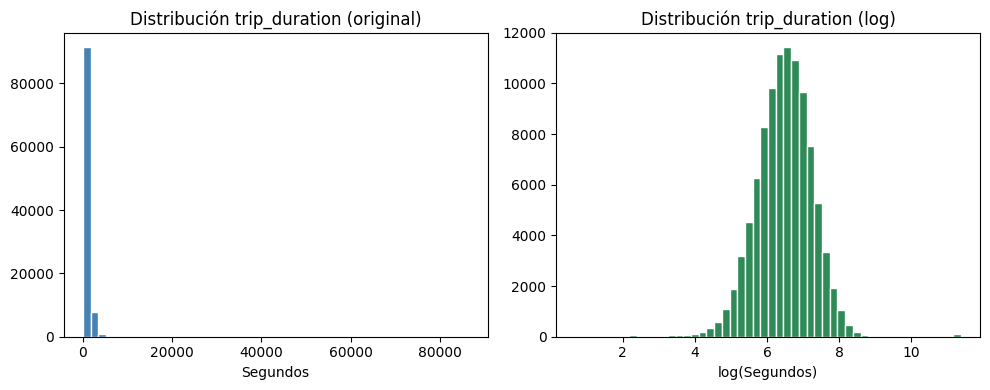

In [4]:
# Visualizamos la distribución de la variable objetivo
# Usamos log1p para ver mejor la distribución (hay valores extremos)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['trip_duration'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución trip_duration (original)')
plt.xlabel('Segundos')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['trip_duration']), bins=50, color='seagreen', edgecolor='white')
plt.title('Distribución trip_duration (log)')
plt.xlabel('log(Segundos)')

plt.tight_layout()
plt.show()

## 4. Limpieza de datos

Eliminamos filas con valores extremos que podrían distorsionar el modelo:
- Viajes de menos de 10 segundos (probablemente errores)
- Viajes de más de 2 horas (outliers extremos)

In [5]:
# Filtramos viajes con duración razonable (entre 10 segundos y 7200 segundos = 2 horas)
df = df[(df['trip_duration'] >= 10) & (df['trip_duration'] <= 7200)]

print(f'Filas después de filtrar outliers: {len(df)}')

Filas después de filtrar outliers: 99735


## 5. Ingeniería de features

Creamos nuevas variables a partir de las existentes para mejorar el modelo:
- **Distancia haversine**: distancia en km entre origen y destino
- **Variables de tiempo**: hora del día, día de la semana, mes
- **Variable objetivo en log**: predecir log(duration) da mejores resultados en regresión

In [6]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia en kilómetros entre dos puntos geográficos
    usando la fórmula de Haversine.
    
    Args:
        lat1, lon1: Coordenadas del punto de origen
        lat2, lon2: Coordenadas del punto de destino
    
    Returns:
        Distancia en kilómetros (float)
    """
    R = 6371  # Radio de la Tierra en km
    
    # Convertimos grados a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


# Calculamos la distancia entre origen y destino
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Convertimos la columna de fecha/hora a tipo datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Extraemos variables de tiempo
df['hour']       = df['pickup_datetime'].dt.hour        # Hora del día (0-23)
df['day_of_week']= df['pickup_datetime'].dt.dayofweek   # Día de la semana (0=lunes)
df['month']      = df['pickup_datetime'].dt.month       # Mes del año

# Convertimos vendor_id a numérico (1 o 2)
df['vendor_id'] = df['vendor_id'].astype(int)

# Variable objetivo en escala logarítmica para mejorar el modelo
df['log_duration'] = np.log1p(df['trip_duration'])

print('Features creadas:')
print(df[['distance_km', 'hour', 'day_of_week', 'month', 'log_duration']].head())

Features creadas:
   distance_km  hour  day_of_week  month  log_duration
0     1.498521    17            0      3      6.122493
1     1.805507     0            6      6      6.498282
2     6.385098    11            1      1      7.661527
3     1.485498    19            2      4      6.063785
4     1.188588    13            5      3      6.077642


## 6. Preparación del conjunto de entrenamiento

Seleccionamos las features que usará el modelo y dividimos en train/test (80/20).

In [7]:
# Lista de features que usará el modelo
FEATURES = [
    'vendor_id',
    'passenger_count',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'distance_km',
    'hour',
    'day_of_week',
    'month'
]

TARGET = 'log_duration'  # Predecimos el logaritmo de la duración

X = df[FEATURES]
y = df[TARGET]

# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Tamaño entrenamiento: {X_train.shape}')
print(f'Tamaño prueba:        {X_test.shape}')

Tamaño entrenamiento: (79788, 10)
Tamaño prueba:        (19947, 10)


## 7. Entrenamiento del modelo

Usamos un `RandomForestRegressor` con parámetros moderados para mantener el tiempo de entrenamiento razonable. El modelo se encapsula en un `Pipeline` junto con un `StandardScaler`.

In [8]:
# Creamos un Pipeline: primero escala los datos, luego aplica el modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),                    # Normaliza las features
    ('model', RandomForestRegressor(
        n_estimators=100,    # Número de árboles en el bosque
        max_depth=10,        # Profundidad máxima de cada árbol (evita overfitting)
        n_jobs=-1,           # Usa todos los núcleos disponibles
        random_state=RANDOM_STATE
    ))
])

# Entrenamos el pipeline con los datos de entrenamiento
print('Entrenando el modelo...')
pipeline.fit(X_train, y_train)
print('¡Entrenamiento completado!')

Entrenando el modelo...


¡Entrenamiento completado!


## 8. Evaluación del modelo

Evaluamos el modelo en el conjunto de prueba usando:
- **RMSE** (Root Mean Squared Error): error cuadrático medio en escala log
- **MAE** (Mean Absolute Error): error absoluto medio en segundos (escala original)

In [9]:
# Hacemos predicciones sobre el conjunto de prueba
y_pred_log = pipeline.predict(X_test)

# Convertimos de vuelta a escala original (segundos)
y_pred_sec = np.expm1(y_pred_log)
y_test_sec = np.expm1(y_test)

# Calculamos métricas de evaluación
rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_sec = mean_absolute_error(y_test_sec, y_pred_sec)

print(f'RMSE (escala log):          {rmse:.4f}')
print(f'MAE  (segundos reales):     {mae_sec:.1f} segundos ({mae_sec/60:.1f} minutos)')

RMSE (escala log):          0.3945
MAE  (segundos reales):     210.2 segundos (3.5 minutos)


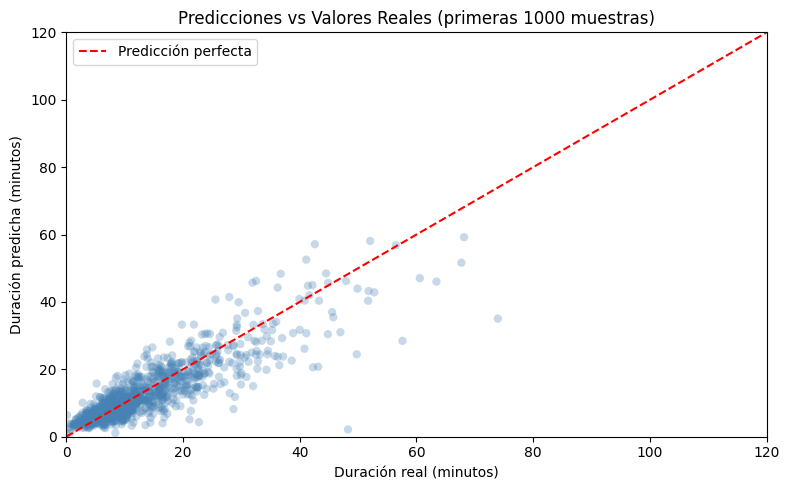

In [10]:
# Visualizamos predicciones vs valores reales
plt.figure(figsize=(8, 5))
plt.scatter(y_test_sec[:1000] / 60, y_pred_sec[:1000] / 60,
            alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([0, 120], [0, 120], 'r--', label='Predicción perfecta')
plt.xlabel('Duración real (minutos)')
plt.ylabel('Duración predicha (minutos)')
plt.title('Predicciones vs Valores Reales (primeras 1000 muestras)')
plt.xlim(0, 120)
plt.ylim(0, 120)
plt.legend()
plt.tight_layout()
plt.show()

### Predicciones vs valores reales

Comparamos la duracion predicha con la real en el conjunto de prueba. Los puntos cercanos a la diagonal indican buen ajuste; la dispersion muestra donde el modelo comete errores mayores.

## 9. Importancia de las features

Vemos cuáles variables aportan más información al modelo.

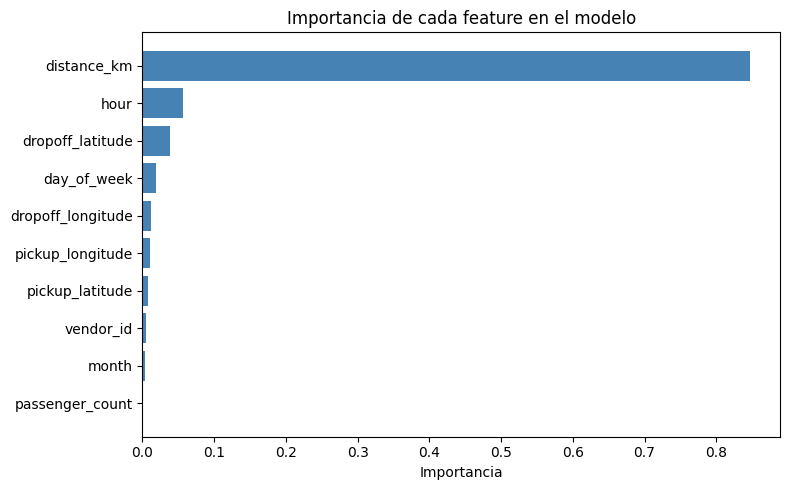

In [11]:
# Extraemos las importancias del modelo dentro del pipeline
importances = pipeline.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': importances
}).sort_values('importance', ascending=True)

# Gráfico de barras horizontales
plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'],
         color='steelblue')
plt.xlabel('Importancia')
plt.title('Importancia de cada feature en el modelo')
plt.tight_layout()
plt.show()

## 10. Guardado del modelo

Guardamos el pipeline entrenado en disco usando `joblib`. Este archivo será usado por `predict.py` y `train.py` en la Fase 2.

In [12]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "taxi_model.joblib"
joblib.dump(pipeline, MODEL_PATH)
joblib.dump(FEATURES, MODEL_DIR / "features.joblib")

print(f"Modelo guardado en: {MODEL_PATH}")

Modelo guardado en: /home/alexizher/Documents/cursos/modelos-sistemas-1/nyc-taxi-trip-duration/fase-1/model/taxi_model.joblib


## 11. Prueba de predicción con datos nuevos

Simulamos cómo se usaría el modelo cargado para hacer una predicción con datos nuevos, tal como lo hará `predict.py` en la Fase 2.

In [13]:
# Cargamos el modelo desde disco (simulando el flujo de producción)
loaded_pipeline = joblib.load(MODEL_DIR / "taxi_model.joblib")
loaded_features = joblib.load(MODEL_DIR / "features.joblib")

# Creamos un ejemplo de viaje nuevo
nuevo_viaje = pd.DataFrame([{
    'vendor_id': 1,
    'passenger_count': 1,
    'pickup_longitude': -73.982155,
    'pickup_latitude': 40.767937,
    'dropoff_longitude': -73.964630,
    'dropoff_latitude': 40.765602,
    'distance_km': 1.5,
    'hour': 9,
    'day_of_week': 1,  # Martes
    'month': 3
}])

# Hacemos la predicción y la convertimos de log a segundos
log_pred = loaded_pipeline.predict(nuevo_viaje[loaded_features])[0]
segundos = np.expm1(log_pred)

print(f'Duración predicha: {segundos:.0f} segundos ({segundos/60:.1f} minutos)')

Duración predicha: 677 segundos (11.3 minutos)


---
## Resumen

| Paso | Descripción |
|------|-------------|
| Dataset | NYC Taxi Trip Duration (Kaggle) |
| Modelo | RandomForestRegressor (sklearn) |
| Features | Coordenadas, distancia haversine, hora, día, mes |
| Target | log(trip_duration) |
| Archivo guardado | `fase-1/model/taxi_model.joblib` |

El modelo y las features quedan en `fase-1/model/` y en la **Fase 2** los usarán `predict.py` y `train.py`.